In [13]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import json
import shutil

print("All imports successful!")

All imports successful!


In [14]:
# Paths
BASE_DIR      = Path("D:/MaternaVision")
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
TRAIN_DIR     = RAW_DIR  / "training_set"
TEST_DIR      = RAW_DIR  / "test_set"
TRAIN_CSV     = RAW_DIR  / "training_set_pixel_size_and_HC.csv"
TEST_CSV      = RAW_DIR  / "test_set_pixel_size.csv"

# Target image size
IMAGE_SIZE = 256

# Create processed folders
(PROCESSED_DIR / "images" / "train").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "images" / "val").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "images" / "test").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "masks"  / "train").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "masks"  / "val").mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / "landmarks").mkdir(parents=True, exist_ok=True)

print("All folders created!")
print(f"Processing images to size: {IMAGE_SIZE}x{IMAGE_SIZE}")

All folders created!
Processing images to size: 256x256


In [15]:
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print("Training CSV columns:", list(df_train.columns))
print("Training samples    :", len(df_train))
print()
print(df_train.head())

Training CSV columns: ['filename', 'pixel size(mm)', 'head circumference (mm)']
Training samples    : 999

     filename  pixel size(mm)  head circumference (mm)
0  000_HC.png        0.069136                    44.30
1  001_HC.png        0.089659                    56.81
2  002_HC.png        0.062033                    68.75
3  003_HC.png        0.091291                    69.00
4  004_HC.png        0.061240                    59.81


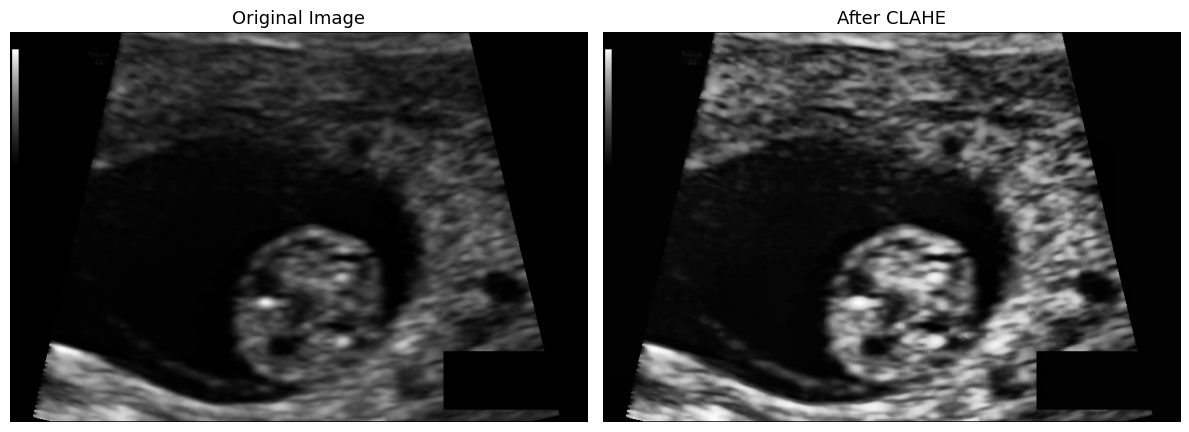

CLAHE working correctly!


In [16]:
def apply_clahe(image):
   
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    return clahe.apply(image)


# Test CLAHE on one image
sample_path = list(TRAIN_DIR.glob("*_HC.png"))[0]
sample_img  = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
clahe_img   = apply_clahe(sample_img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(sample_img,  cmap='gray')
axes[0].set_title('Original Image', fontsize=13)
axes[0].axis('off')
axes[1].imshow(clahe_img, cmap='gray')
axes[1].set_title('After CLAHE', fontsize=13)
axes[1].axis('off')
plt.tight_layout()
plt.savefig('clahe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("CLAHE working correctly!")

In [17]:
def resize_image(image, target_size=256):
    """Resize image to target size."""
    return cv2.resize(
        image,
        (target_size, target_size),
        interpolation=cv2.INTER_LINEAR
    )


def resize_mask(mask, target_size=256):
    """Resize binary mask to target size."""
    return cv2.resize(
        mask,
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )


def scale_landmarks(landmarks, original_h, original_w,
                    target_size=256):
    """Scale landmark coordinates proportionally."""
    scale_x = target_size / original_w
    scale_y = target_size / original_h

    scaled = landmarks.copy()
    scaled['bpd_x1'] *= scale_x
    scaled['bpd_x2'] *= scale_x
    scaled['ofd_x1'] *= scale_x
    scaled['ofd_x2'] *= scale_x
    scaled['bpd_y1'] *= scale_y
    scaled['bpd_y2'] *= scale_y
    scaled['ofd_y1'] *= scale_y
    scaled['ofd_y2'] *= scale_y

    return scaled


# Test resize
resized = resize_image(sample_img, IMAGE_SIZE)
print(f"Original size : {sample_img.shape}")
print(f"Resized size  : {resized.shape}")

Original size : (540, 800)
Resized size  : (256, 256)


In [18]:
def extract_ellipse(mask_path):
  
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)

    if len(largest) < 5:
        return None

    ellipse = cv2.fitEllipse(largest)
    center, axes, angle = ellipse

    return {
        'center_x': center[0],
        'center_y': center[1],
        'axis_a'  : axes[0] / 2,
        'axis_b'  : axes[1] / 2,
        'angle'   : angle
    }


# Test
sample_mask_path = str(sample_path).replace(
    "_HC.png", "_HC_Annotation.png"
)
ellipse = extract_ellipse(sample_mask_path)
print("Ellipse extracted:")
print(f"  Center : ({ellipse['center_x']:.1f}, {ellipse['center_y']:.1f})")
print(f"  Axis A : {ellipse['axis_a']:.1f} px")
print(f"  Axis B : {ellipse['axis_b']:.1f} px")
print(f"  Angle  : {ellipse['angle']:.1f} degrees")

Ellipse extracted:
  Center : (409.4, 377.8)
  Axis A : 93.6 px
  Axis B : 111.7 px
  Angle  : 23.6 degrees


In [19]:
def extract_landmarks(ellipse):
    """
    Extract 4 landmark points from ellipse:
    - BPD point 1 and 2 (minor axis endpoints)
    - OFD point 1 and 2 (major axis endpoints)
    """
    if ellipse is None:
        return None

    cx    = ellipse['center_x']
    cy    = ellipse['center_y']
    a     = ellipse['axis_a']
    b     = ellipse['axis_b']
    angle = np.radians(ellipse['angle'])

    cos_a = np.cos(angle)
    sin_a = np.sin(angle)

    # BPD — minor axis endpoints
    bpd_x1 = cx + a * (-sin_a)
    bpd_y1 = cy + a * cos_a
    bpd_x2 = cx - a * (-sin_a)
    bpd_y2 = cy - a * cos_a

    # OFD — major axis endpoints
    ofd_x1 = cx + b * cos_a
    ofd_y1 = cy + b * sin_a
    ofd_x2 = cx - b * cos_a
    ofd_y2 = cy - b * sin_a

    return {
        'bpd_x1': round(bpd_x1, 4),
        'bpd_y1': round(bpd_y1, 4),
        'bpd_x2': round(bpd_x2, 4),
        'bpd_y2': round(bpd_y2, 4),
        'ofd_x1': round(ofd_x1, 4),
        'ofd_y1': round(ofd_y1, 4),
        'ofd_x2': round(ofd_x2, 4),
        'ofd_y2': round(ofd_y2, 4),
    }


# Test
landmarks = extract_landmarks(ellipse)
print("Landmarks extracted:")
for k, v in landmarks.items():
    print(f"  {k} : {v}")

Landmarks extracted:
  bpd_x1 : 371.9212
  bpd_y1 : 463.542
  bpd_x2 : 446.9763
  bpd_y2 : 292.0365
  ofd_x1 : 511.7646
  ofd_y1 : 422.5652
  ofd_x2 : 307.1329
  ofd_y2 : 333.0132


In [20]:
def calculate_measurements(landmarks, pixel_size):
    
    # BPD = distance between BPD points
    bpd_px = np.sqrt(
        (landmarks['bpd_x2'] - landmarks['bpd_x1'])**2 +
        (landmarks['bpd_y2'] - landmarks['bpd_y1'])**2
    )

    # OFD = distance between OFD points
    ofd_px = np.sqrt(
        (landmarks['ofd_x2'] - landmarks['ofd_x1'])**2 +
        (landmarks['ofd_y2'] - landmarks['ofd_y1'])**2
    )

    bpd_mm = bpd_px * pixel_size
    ofd_mm = ofd_px * pixel_size

    return {
        'bpd_px': round(bpd_px, 4),
        'ofd_px': round(ofd_px, 4),
        'bpd_mm': round(bpd_mm, 4),
        'ofd_mm': round(ofd_mm, 4),
    }


# Test with first image pixel size
pixel_size = df_train.iloc[0]['pixel size(mm)']
measurements = calculate_measurements(landmarks, pixel_size)
print("Measurements:")
print(f"  BPD : {measurements['bpd_mm']:.2f} mm")
print(f"  OFD : {measurements['ofd_mm']:.2f} mm")
print(f"  HC  : {df_train.iloc[0]['head circumference (mm)']:.2f} mm (from CSV)")

Measurements:
  BPD : 12.94 mm
  OFD : 15.44 mm
  HC  : 44.30 mm (from CSV)


In [21]:
def preprocess_one(img_path, mask_path, pixel_size,
                   target_size=256):
    """
    Full preprocessing pipeline for one image:
    1. Load image and mask
    2. Apply CLAHE
    3. Extract ellipse and landmarks
    4. Resize image and mask
    5. Scale landmarks
    6. Return all processed data
    """
    # Load
    image = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
    mask  = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if image is None or mask is None:
        return None

    original_h, original_w = image.shape

    # Extract ellipse and landmarks BEFORE resizing
    ellipse   = extract_ellipse(mask_path)
    landmarks = extract_landmarks(ellipse)

    if landmarks is None:
        return None

    # Calculate measurements in mm
    measurements = calculate_measurements(landmarks, pixel_size)

    # Apply CLAHE
    image_clahe = apply_clahe(image)

    # Resize image and mask
    image_resized = resize_image(image_clahe, target_size)
    mask_resized  = resize_mask(mask, target_size)
    mask_binary   = (mask_resized > 127).astype(np.uint8) * 255

    # Scale landmarks to new size
    landmarks_scaled = scale_landmarks(
        landmarks, original_h, original_w, target_size
    )

    return {
        'image'           : image_resized,
        'mask'            : mask_binary,
        'landmarks'       : landmarks_scaled,
        'measurements'    : measurements,
        'original_size'   : (original_h, original_w),
    }


# Test on first image
result = preprocess_one(
    img_path   = sample_path,
    mask_path  = sample_mask_path,
    pixel_size = df_train.iloc[0]['pixel size(mm)'],
    target_size= IMAGE_SIZE
)

print("Preprocessing result:")
print(f"  Image shape    : {result['image'].shape}")
print(f"  Mask shape     : {result['mask'].shape}")
print(f"  BPD            : {result['measurements']['bpd_mm']:.2f} mm")
print(f"  OFD            : {result['measurements']['ofd_mm']:.2f} mm")
print(f"  Original size  : {result['original_size']}")

Preprocessing result:
  Image shape    : (256, 256)
  Mask shape     : (256, 256)
  BPD            : 12.94 mm
  OFD            : 15.44 mm
  Original size  : (540, 800)


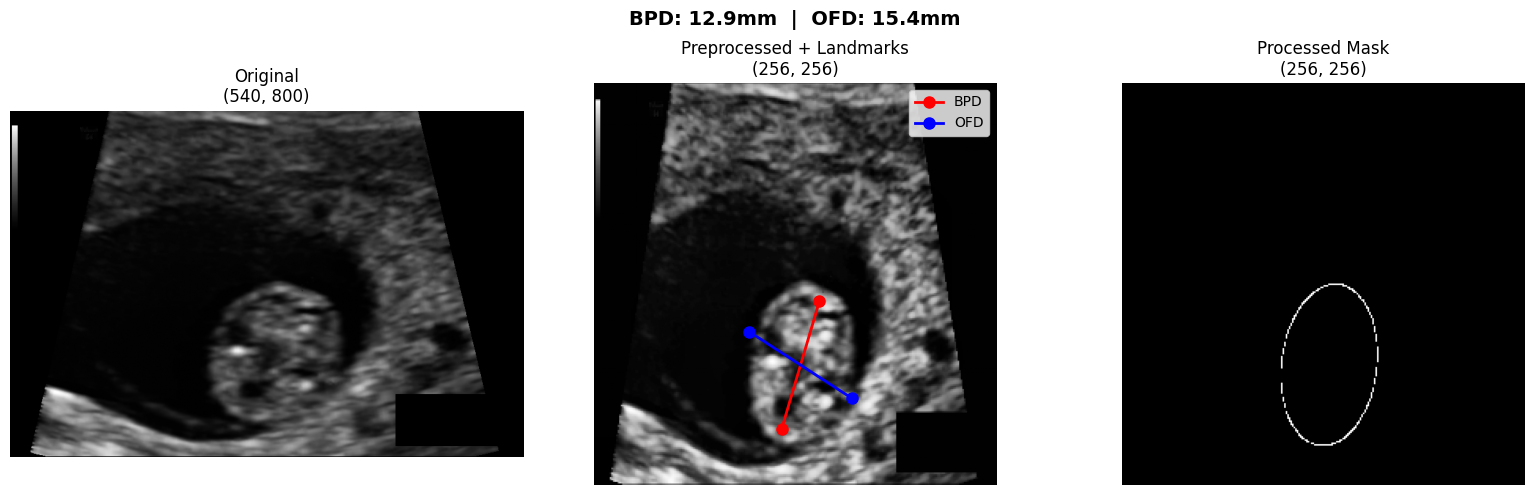

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Original
original = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
axes[0].imshow(original, cmap='gray')
axes[0].set_title(f'Original\n{original.shape}', fontsize=12)
axes[0].axis('off')

# Preprocessed image
axes[1].imshow(result['image'], cmap='gray')
lm = result['landmarks']
axes[1].plot(
    [lm['bpd_x1'], lm['bpd_x2']],
    [lm['bpd_y1'], lm['bpd_y2']],
    'r-o', linewidth=2, markersize=8, label='BPD'
)
axes[1].plot(
    [lm['ofd_x1'], lm['ofd_x2']],
    [lm['ofd_y1'], lm['ofd_y2']],
    'b-o', linewidth=2, markersize=8, label='OFD'
)
axes[1].legend(fontsize=10)
axes[1].set_title(
    f'Preprocessed + Landmarks\n{result["image"].shape}',
    fontsize=12
)
axes[1].axis('off')

# Mask
axes[2].imshow(result['mask'], cmap='gray')
axes[2].set_title(f'Processed Mask\n{result["mask"].shape}', fontsize=12)
axes[2].axis('off')

plt.suptitle(
    f'BPD: {result["measurements"]["bpd_mm"]:.1f}mm  |  '
    f'OFD: {result["measurements"]["ofd_mm"]:.1f}mm',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('preprocessing_result.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Get all training images
all_train_images = sorted([
    f for f in TRAIN_DIR.glob("*_HC.png")
    if "Annotation" not in f.name
])

print(f"Total training images to process: {len(all_train_images)}")
print("Starting preprocessing...")

# Store all annotations
annotations = []
failed      = []

for img_path in tqdm(all_train_images, desc="Processing"):

    # Get image name without extension
    img_name = img_path.stem  # e.g. 001_HC

    # Mask path
    mask_path = TRAIN_DIR / f"{img_name}_Annotation.png"

    if not mask_path.exists():
        failed.append(img_name)
        continue

    # Get pixel size from CSV
    row = df_train[
        df_train['filename'] == img_path.name
    ]
    if len(row) == 0:
        failed.append(img_name)
        continue

    pixel_size = row.iloc[0]['pixel size(mm)']
    hc_mm      = row.iloc[0]['head circumference (mm)']

    # Preprocess
    result = preprocess_one(
        img_path    = img_path,
        mask_path   = mask_path,
        pixel_size  = pixel_size,
        target_size = IMAGE_SIZE
    )

    if result is None:
        failed.append(img_name)
        continue

    # Save image
    cv2.imwrite(
        str(PROCESSED_DIR / "images" / "train" / f"{img_name}.png"),
        result['image']
    )

    # Save mask
    cv2.imwrite(
        str(PROCESSED_DIR / "masks" / "train" / f"{img_name}.png"),
        result['mask']
    )

    # Store annotation
    annotations.append({
        'image_name'  : f"{img_name}.png",
        'bpd_x1'     : result['landmarks']['bpd_x1'],
        'bpd_y1'     : result['landmarks']['bpd_y1'],
        'bpd_x2'     : result['landmarks']['bpd_x2'],
        'bpd_y2'     : result['landmarks']['bpd_y2'],
        'ofd_x1'     : result['landmarks']['ofd_x1'],
        'ofd_y1'     : result['landmarks']['ofd_y1'],
        'ofd_x2'     : result['landmarks']['ofd_x2'],
        'ofd_y2'     : result['landmarks']['ofd_y2'],
        'bpd_mm'     : result['measurements']['bpd_mm'],
        'ofd_mm'     : result['measurements']['ofd_mm'],
        'hc_mm'      : hc_mm,
        'pixel_size' : pixel_size,
    })

print(f"\nProcessed successfully : {len(annotations)}")
print(f"Failed                 : {len(failed)}")
if failed:
    print(f"Failed images          : {failed[:5]}")

Total training images to process: 806
Starting preprocessing...


Processing: 100%|██████████| 806/806 [00:07<00:00, 102.12it/s]


Processed successfully : 806
Failed                 : 0


In [ ]:
df_annotations = pd.DataFrame(annotations)

save_path = PROCESSED_DIR / "annotations.csv"
df_annotations.to_csv(save_path, index=False)

print(f"Total records : {len(df_annotations)}")
print(df_annotations.head())

In [ ]:
from sklearn.model_selection import train_test_split

df_train_split, df_val_split = train_test_split(
    df_annotations,
    test_size    = 0.2,
    random_state = 42
)

print(f"Training samples   : {len(df_train_split)}")
print(f"Validation samples : {len(df_val_split)}")

In [24]:
# Count files in each folder
train_imgs = list((PROCESSED_DIR / "images" / "train").glob("*.png"))
val_imgs   = list((PROCESSED_DIR / "images" / "val").glob("*.png"))
test_imgs  = list((PROCESSED_DIR / "images" / "test").glob("*.png"))
train_msks = list((PROCESSED_DIR / "masks"  / "train").glob("*.png"))
val_msks   = list((PROCESSED_DIR / "masks"  / "val").glob("*.png"))

print("=" * 50)
print("   PREPROCESSING COMPLETE — SUMMARY")
print("=" * 50)
print(f"Train images  : {len(train_imgs)}")
print(f"Val images    : {len(val_imgs)}")
print(f"Test images   : {len(test_imgs)}")
print(f"Train masks   : {len(train_msks)}")
print(f"Val masks     : {len(val_msks)}")
print()
print(f"Image size    : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Preprocessing : CLAHE + Resize + Landmark Extraction")
print()
print("CSV files saved:")
print(f"  annotations.csv       — all {len(df_annotations)} samples")
print(f"  train_annotations.csv — {len(train_imgs)} samples")
print(f"  val_annotations.csv   — {len(val_imgs)} samples")
print(f"  test_annotations.csv  — {len(test_imgs)} samples")
print()
print("✅ Data is ready for model training!")
print("=" * 50)

   PREPROCESSING COMPLETE — SUMMARY
Train images  : 806
Val images    : 0
Test images   : 0
Train masks   : 806
Val masks     : 0

Image size    : 256x256
Preprocessing : CLAHE + Resize + Landmark Extraction

CSV files saved:


NameError: name 'df_annotations' is not defined